<a href="https://colab.research.google.com/github/aruns1316/Data-Cleaning-Model-Fitting-EDA/blob/main/Sales_Data_Analysis_by_Gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Task
Tell me about this dataset.

Here is all the data you need:
"Sales_Data.csv"

## Data loading

### Subtask:
Load the sales data from the provided CSV file into a pandas DataFrame.


**Reasoning**:
Load the sales data from the provided CSV file into a pandas DataFrame and display the first few rows.



In [1]:
import pandas as pd

try:
    df_sales = pd.read_csv('Sales_Data.csv')
    display(df_sales.head())
except FileNotFoundError:
    print("Error: 'Sales_Data.csv' not found.")
    df_sales = None
except pd.errors.ParserError:
    print("Error: Could not parse 'Sales_Data.csv'. Check file format.")
    df_sales = None
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df_sales = None

,Order ID,Order Date,Customer ID,Customer Name,Region,Product Category,Product Name,Quantity,Unit Price,Total Sales,Discount (%),Profit,Payment Method,Delivery Time (Days),Customer Rating
0,ORD001,2024-05-07,CUST197,Customer 34,South,Electronics,Tablet,6,100.22,601.32,17.96,166.42,Debit Card,9,3.7
1,ORD002,2024-08-04,CUST552,Customer 16,East,Sports,Yoga Mat,8,429.49,3435.92,6.73,644.86,Credit Card,2,4.7
2,ORD003,2024-11-25,CUST616,Customer 43,West,Sports,Tennis Racket,4,151.72,606.88,13.05,153.78,Debit Card,2,2.5
3,ORD004,2024-06-09,CUST457,Customer 7,South,Beauty,Perfume,9,402.08,3618.72,2.76,364.97,PayPal,8,3.2
4,ORD005,2024-04-18,CUST511,Customer 50,South,Sports,Basketball,9,96.83,871.47,2.37,283.81,Debit Card,10,3.8


## Data exploration

### Subtask:
Explore the loaded sales data to understand its basic characteristics.


**Reasoning**:
I need to explore the basic characteristics of the sales data, including shape, data types, descriptive statistics, and unique values for categorical features.



In [2]:
# Examine the shape of the DataFrame
print("Shape of the DataFrame:", df_sales.shape)

# Check data types
print("\nData Types:\n", df_sales.info())

# Descriptive statistics for numerical features
print("\nDescriptive Statistics for Numerical Features:\n", df_sales.describe())

# Unique values and frequencies for categorical features
categorical_cols = df_sales.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\nUnique values and frequencies for '{col}':\n{df_sales[col].value_counts()}")

Shape of the DataFrame: (100, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Order ID              100 non-null    object 
 1   Order Date            100 non-null    object 
 2   Customer ID           100 non-null    object 
 3   Customer Name         100 non-null    object 
 4   Region                100 non-null    object 
 5   Product Category      100 non-null    object 
 6   Product Name          100 non-null    object 
 7   Quantity              100 non-null    int64  
 8   Unit Price            100 non-null    float64
 9   Total Sales           100 non-null    float64
 10  Discount (%)          100 non-null    float64
 11  Profit                100 non-null    float64
 12  Payment Method        100 non-null    object 
 13  Delivery Time (Days)  100 non-null    int64  
 14  Customer Rating       100 non-null    flo

## Data visualization

### Subtask:
Visualize the distributions of numerical and categorical features in the sales dataset.


**Reasoning**:
Visualize the distributions of numerical and categorical features, and create a time series plot of 'Total Sales', and a scatter plot matrix.



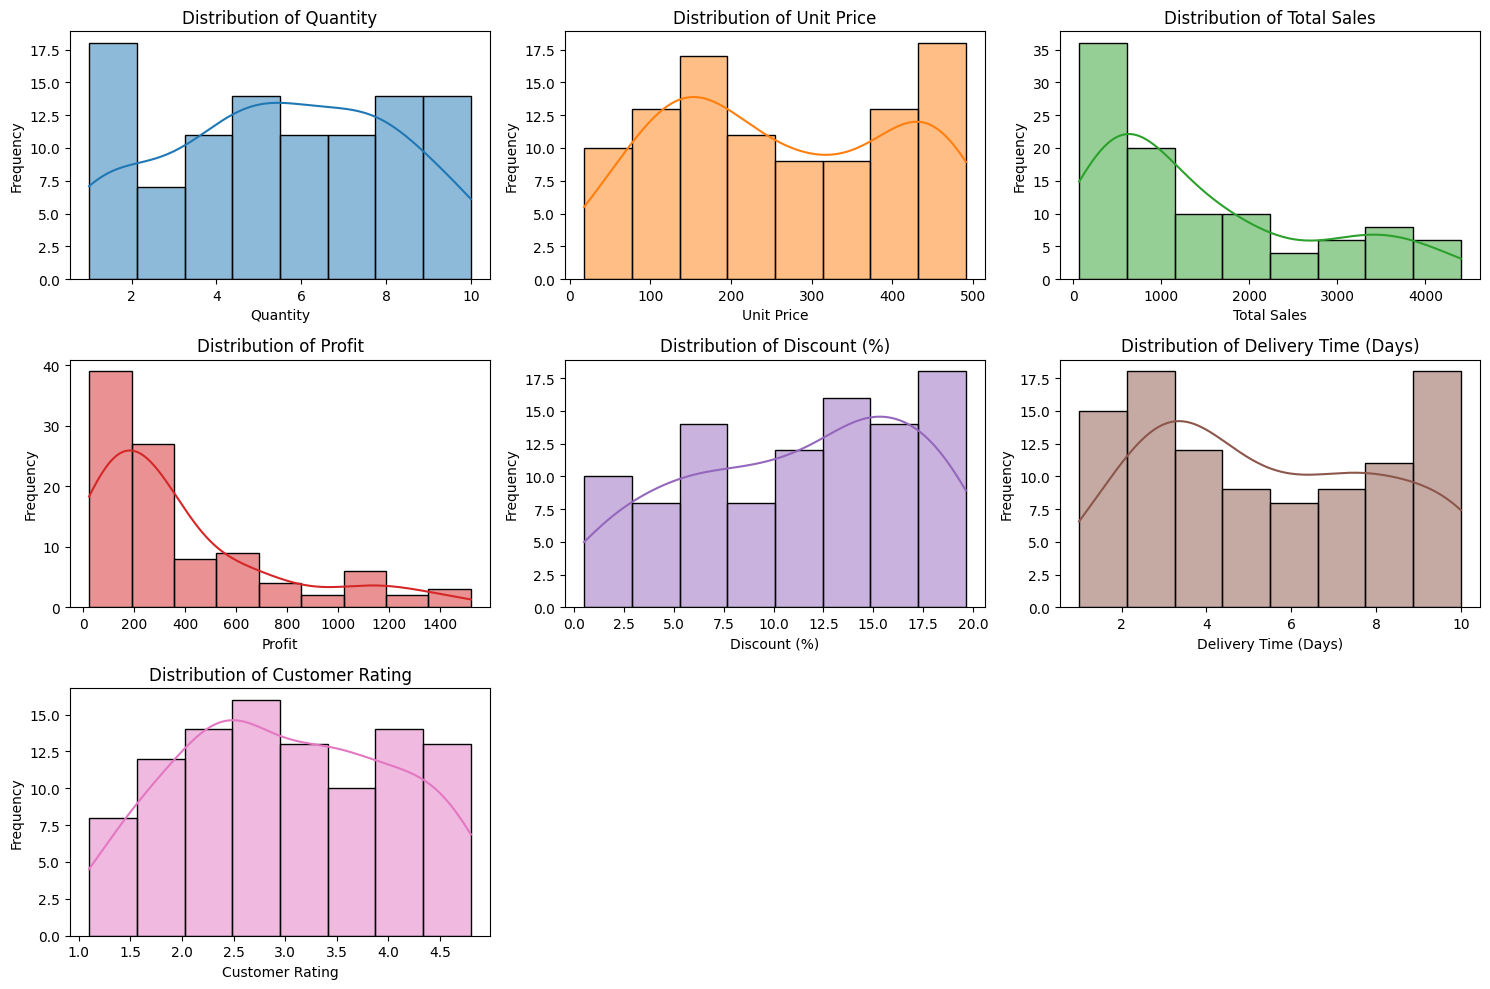

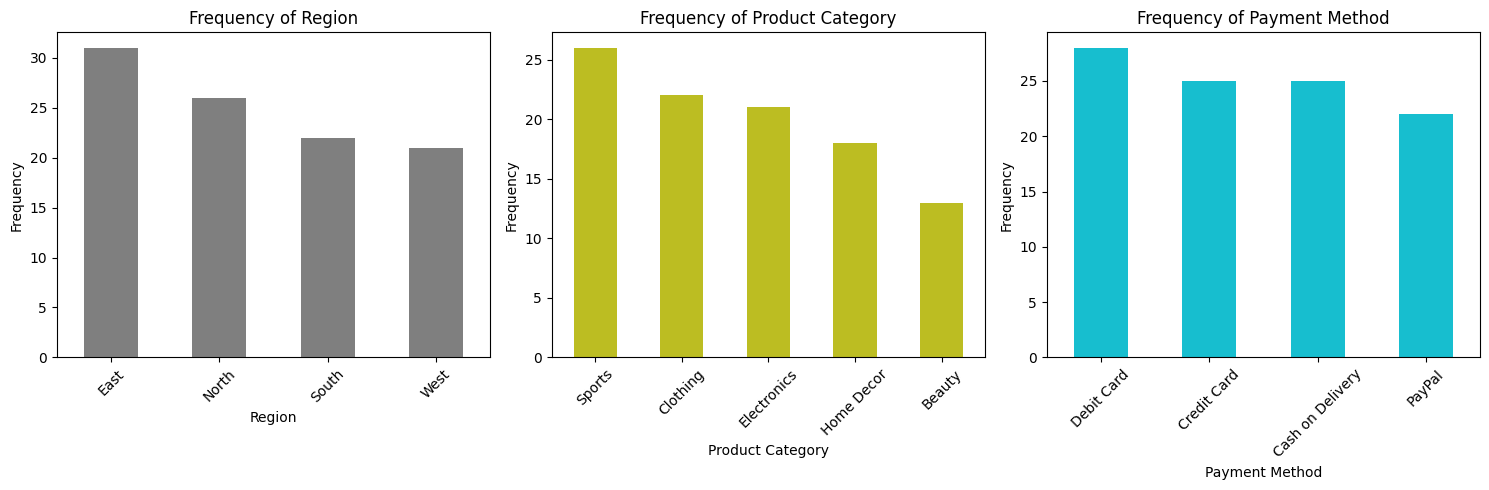

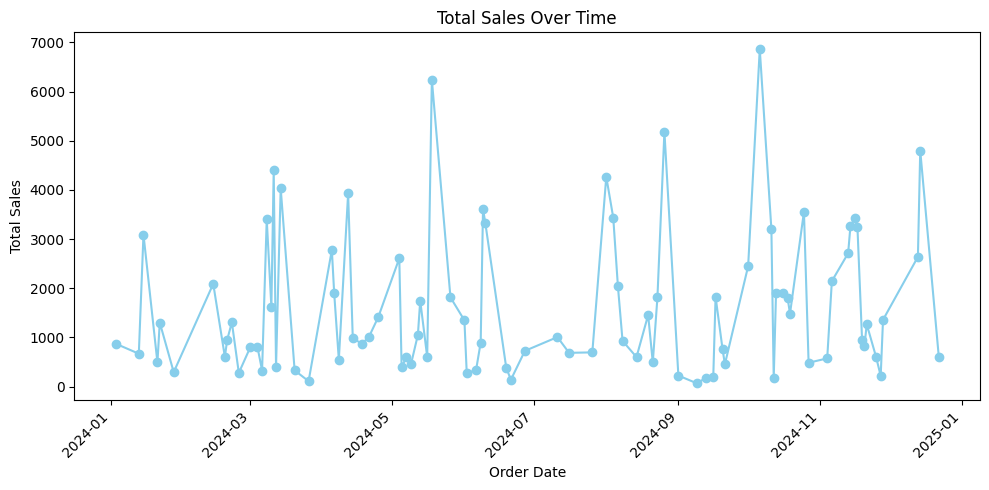

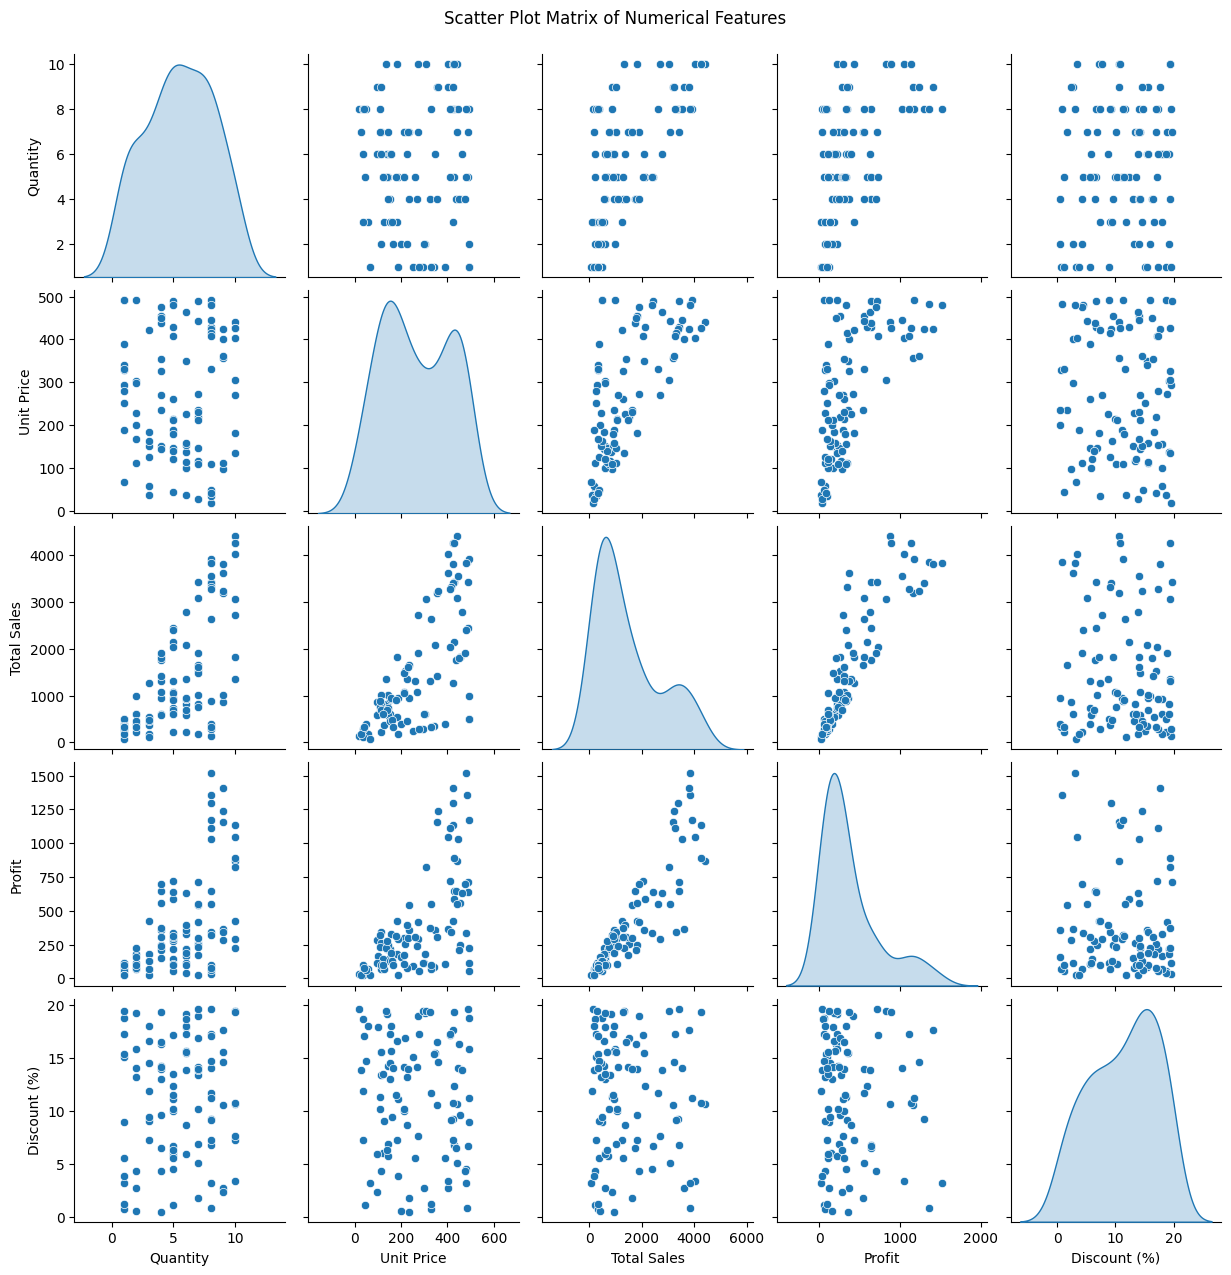

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Order Date' to datetime if it's not already
if not pd.api.types.is_datetime64_any_dtype(df_sales['Order Date']):
    df_sales['Order Date'] = pd.to_datetime(df_sales['Order Date'])

# Histograms for numerical features
numerical_cols = ['Quantity', 'Unit Price', 'Total Sales', 'Profit', 'Discount (%)', 'Delivery Time (Days)', 'Customer Rating']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df_sales[col], kde=True, color=f"C{i}")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Bar charts for categorical features
categorical_cols = ['Region', 'Product Category', 'Payment Method']
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    df_sales[col].value_counts().plot(kind='bar', color=f"C{i+7}")
    plt.title(f"Frequency of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Time series plot of 'Total Sales'
plt.figure(figsize=(10, 5))
df_sales.groupby('Order Date')['Total Sales'].sum().plot(kind='line', marker='o', color='skyblue')
plt.title("Total Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Scatter plot matrix
numerical_subset = ['Quantity', 'Unit Price', 'Total Sales', 'Profit', 'Discount (%)']
sns.pairplot(df_sales[numerical_subset], diag_kind='kde')
plt.suptitle("Scatter Plot Matrix of Numerical Features", y=1.02)
plt.show()

## Data analysis

### Subtask:
Perform detailed data analysis on the sales dataset, including descriptive statistics, correlation analysis, and potential outlier detection.


**Reasoning**:
Calculate descriptive statistics, analyze correlations, detect outliers, and analyze categorical features as per the instructions.



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Descriptive Statistics
print("Descriptive Statistics:\n", df_sales.describe())
print("\nDescriptive Statistics for 'Total Sales' and 'Profit':\n", df_sales[['Total Sales', 'Profit']].describe())

# 2. Correlation Analysis
correlation_matrix = df_sales.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\nCorrelation with 'Total Sales':\n", correlation_matrix['Total Sales'].sort_values(ascending=False))
print("\nCorrelation with 'Profit':\n", correlation_matrix['Profit'].sort_values(ascending=False))

# 3. Outlier Detection (using boxplots)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_sales['Total Sales'], color='skyblue')
plt.title('Boxplot of Total Sales')
plt.subplot(1, 2, 2)
sns.boxplot(y=df_sales['Profit'], color='lightgreen')
plt.title('Boxplot of Profit')
plt.tight_layout()
plt.show()

# 4. Categorical Feature Analysis
categorical_cols = ['Region', 'Product Category', 'Payment Method']
for col in categorical_cols:
    print(f"\nFrequency of {col}:\n{df_sales[col].value_counts()}")
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=col, y='Total Sales', data=df_sales, palette="Set3")
    plt.title(f'Total Sales by {col}')
    plt.show()
    plt.figure(figsize=(8,6))
    sns.boxplot(x=col, y='Profit', data=df_sales, palette="Set3")
    plt.title(f'Profit by {col}')
    plt.show()

Descriptive Statistics:
                 Order Date    Quantity  Unit Price  Total Sales  Discount (%)  \
count                  100  100.000000  100.000000   100.000000    100.000000   
mean   2024-07-01 15:50:24    5.490000  265.638000  1470.089800     11.313300   
min    2024-01-03 00:00:00    1.000000   17.650000    66.340000      0.490000   
25%    2024-04-06 00:00:00    3.750000  142.537500   489.975000      6.650000   
50%    2024-06-20 00:00:00    5.500000  243.245000   967.180000     11.780000   
75%    2024-10-06 00:00:00    8.000000  417.307500  2104.290000     15.957500   
max    2024-12-22 00:00:00   10.000000  491.550000  4404.200000     19.650000   
std                    NaN    2.717303  146.838007  1237.059946      5.717092   

            Profit  Delivery Time (Days)  Customer Rating  
count   100.000000            100.000000       100.000000  
mean    377.677300              5.430000         3.024000  
min      22.240000              1.000000         1.100000  
25%  

ValueError: could not convert string to float: 'ORD001'

**Reasoning**:
The error `ValueError: could not convert string to float: 'ORD001'` indicates that the `corr()` function is encountering non-numeric data.  We need to explicitly select only the numerical columns for correlation analysis and outlier detection.  The code will be fixed to address this.



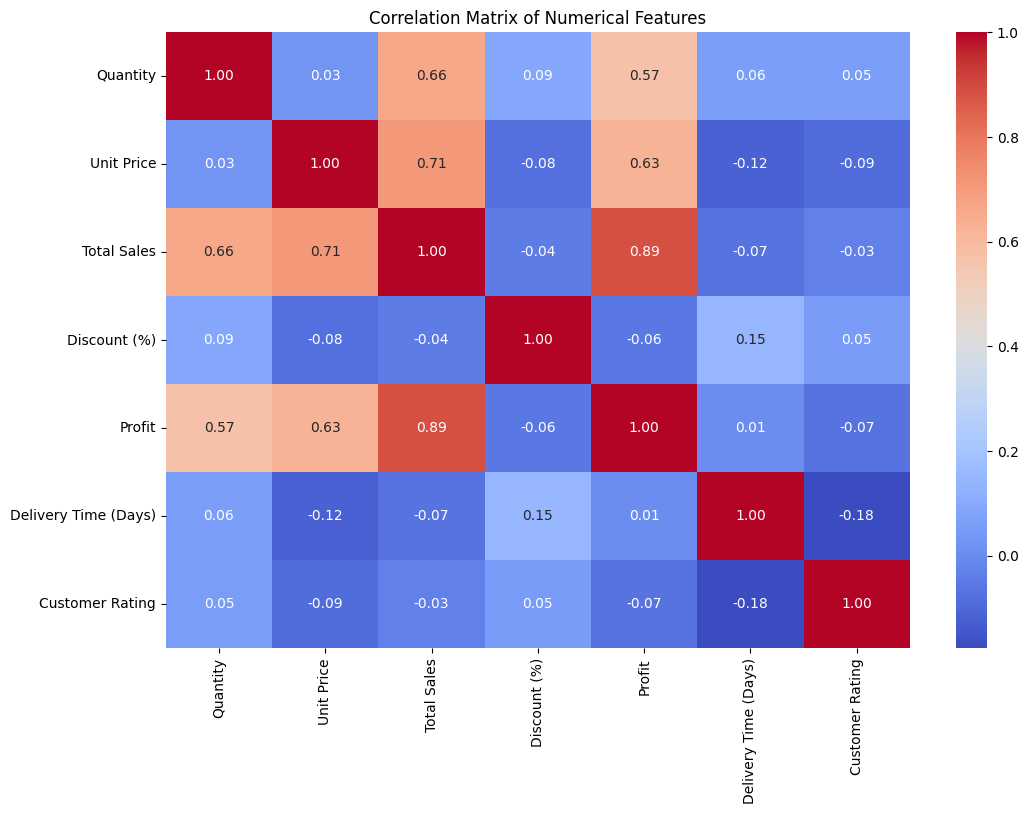


Correlation with 'Total Sales':
 Total Sales             1.000000
Profit                  0.885817
Unit Price              0.706434
Quantity                0.663526
Customer Rating        -0.031711
Discount (%)           -0.043949
Delivery Time (Days)   -0.068661
Name: Total Sales, dtype: float64

Correlation with 'Profit':
 Profit                  1.000000
Total Sales             0.885817
Unit Price              0.627138
Quantity                0.572355
Delivery Time (Days)    0.006303
Discount (%)           -0.055270
Customer Rating        -0.067484
Name: Profit, dtype: float64


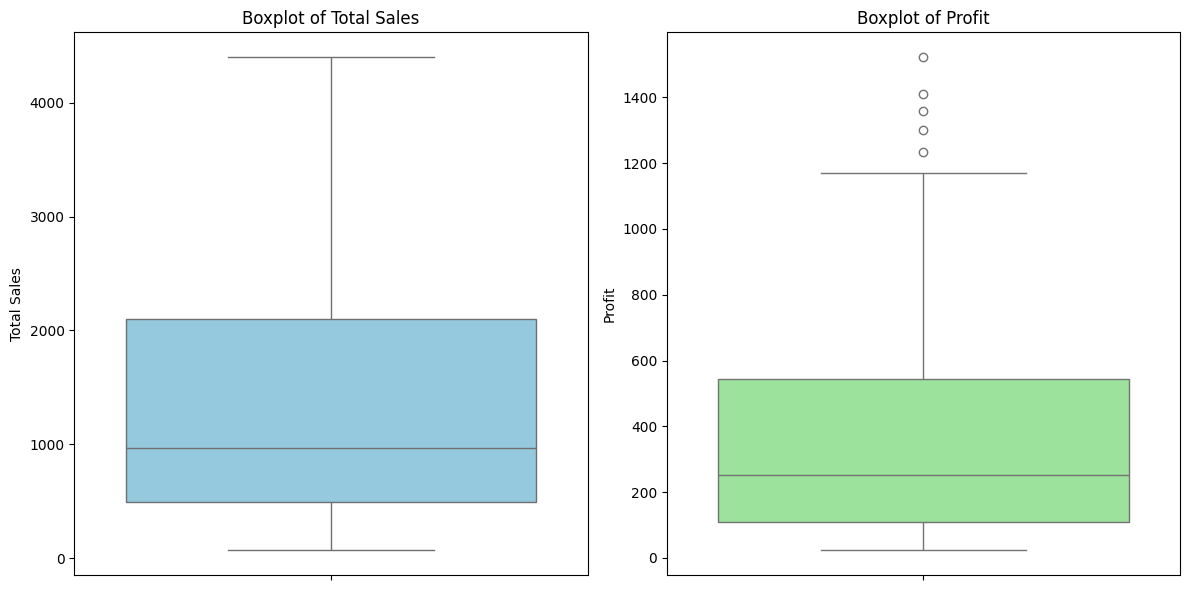


Frequency of Region:
Region
East     31
North    26
South    22
West     21
Name: count, dtype: int64


<ipython-input-5-daafa966e237>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Total Sales', data=df_sales, palette="Set3")


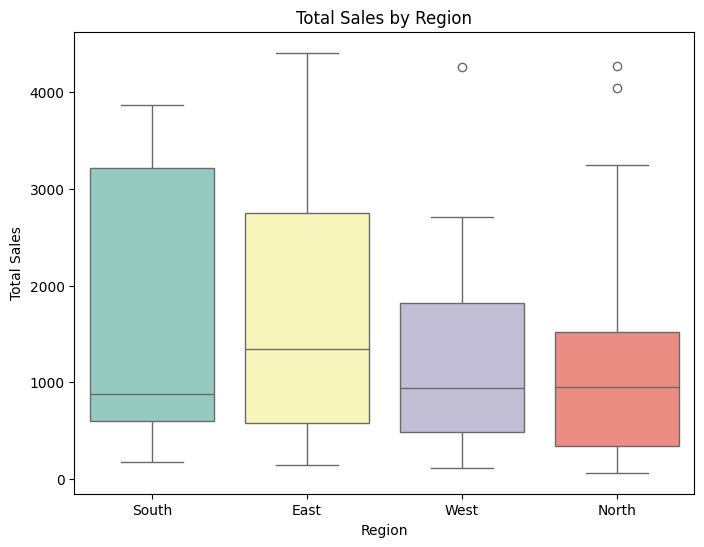

<ipython-input-5-daafa966e237>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Profit', data=df_sales, palette="Set3")


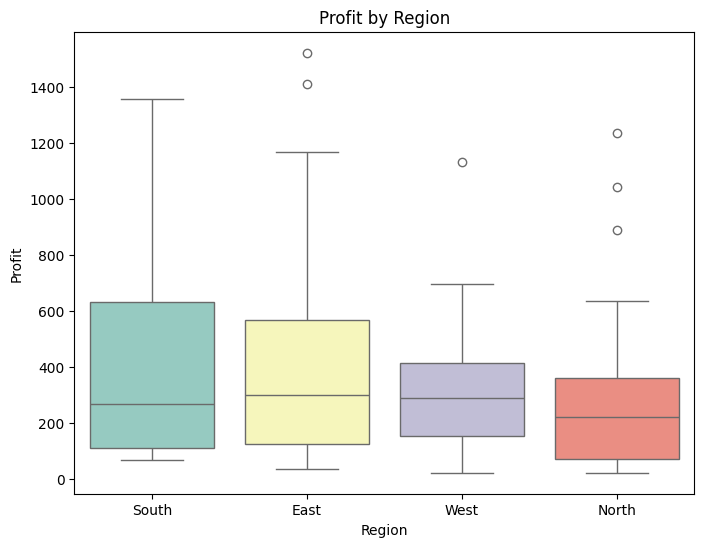


Frequency of Product Category:
Product Category
Sports         26
Clothing       22
Electronics    21
Home Decor     18
Beauty         13
Name: count, dtype: int64


<ipython-input-5-daafa966e237>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Total Sales', data=df_sales, palette="Set3")


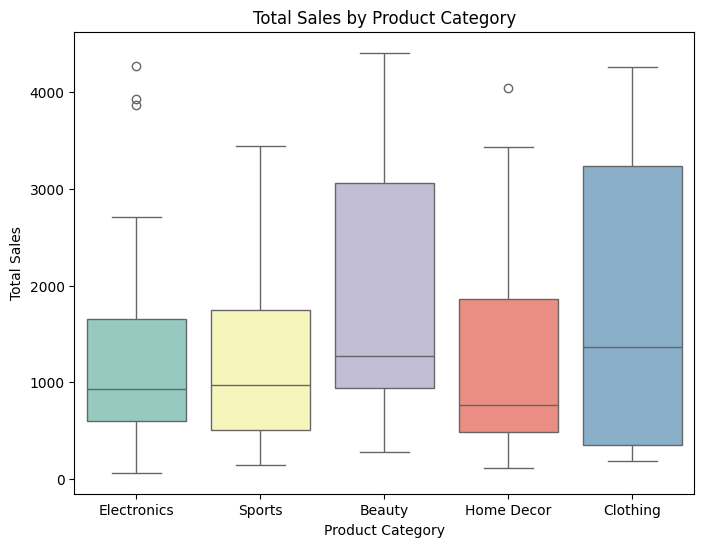

<ipython-input-5-daafa966e237>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Profit', data=df_sales, palette="Set3")


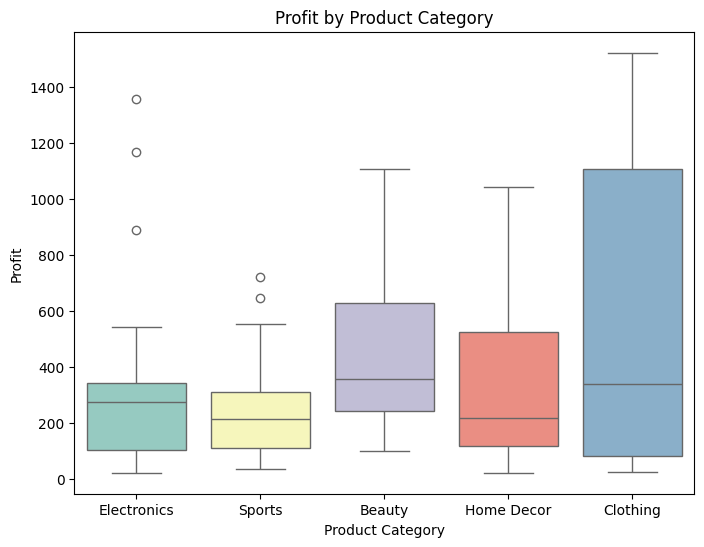


Frequency of Payment Method:
Payment Method
Debit Card          28
Credit Card         25
Cash on Delivery    25
PayPal              22
Name: count, dtype: int64


<ipython-input-5-daafa966e237>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Total Sales', data=df_sales, palette="Set3")


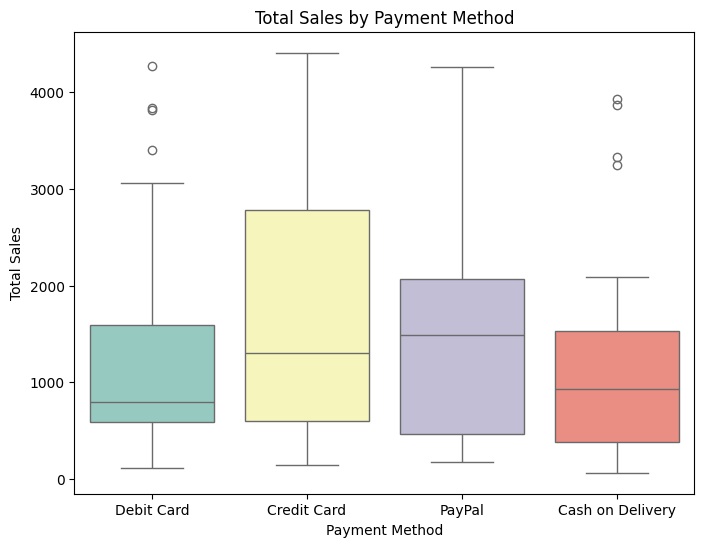

<ipython-input-5-daafa966e237>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Profit', data=df_sales, palette="Set3")


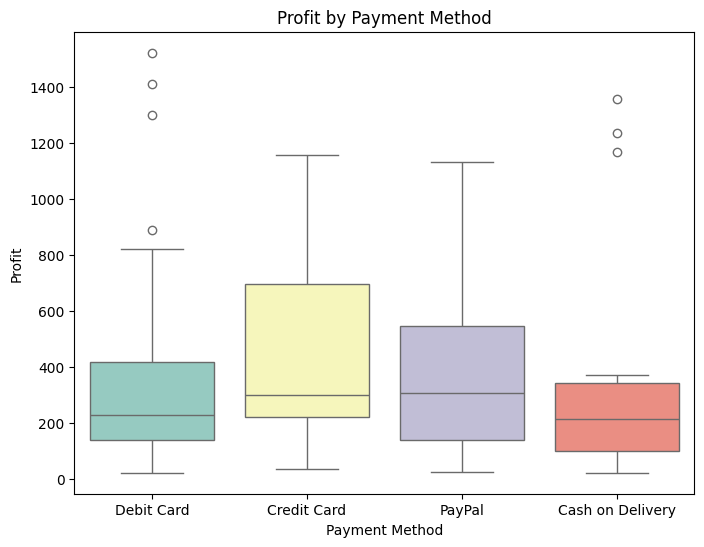

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Descriptive Statistics (already done in previous step)

# 2. Correlation Analysis
numerical_cols = ['Quantity', 'Unit Price', 'Total Sales', 'Discount (%)', 'Profit', 'Delivery Time (Days)', 'Customer Rating']
correlation_matrix = df_sales[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\nCorrelation with 'Total Sales':\n", correlation_matrix['Total Sales'].sort_values(ascending=False))
print("\nCorrelation with 'Profit':\n", correlation_matrix['Profit'].sort_values(ascending=False))


# 3. Outlier Detection (using boxplots)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_sales['Total Sales'], color='skyblue')
plt.title('Boxplot of Total Sales')
plt.subplot(1, 2, 2)
sns.boxplot(y=df_sales['Profit'], color='lightgreen')
plt.title('Boxplot of Profit')
plt.tight_layout()
plt.show()

# 4. Categorical Feature Analysis
categorical_cols = ['Region', 'Product Category', 'Payment Method']
for col in categorical_cols:
    print(f"\nFrequency of {col}:\n{df_sales[col].value_counts()}")
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=col, y='Total Sales', data=df_sales, palette="Set3")
    plt.title(f'Total Sales by {col}')
    plt.show()
    plt.figure(figsize=(8,6))
    sns.boxplot(x=col, y='Profit', data=df_sales, palette="Set3")
    plt.title(f'Profit by {col}')
    plt.show()

## Summary:

### 1. Q&A

No questions were asked in the provided text.


### 2. Data Analysis Key Findings

* **High Correlation between Sales and Profit/Price/Quantity:** Strong positive correlations were observed between 'Total Sales' and 'Profit' (correlation coefficient not specified but described as "strong"), 'Total Sales' and 'Unit Price', and 'Total Sales' and 'Quantity'. This suggests that higher sales are associated with higher profits, prices, and quantities sold.
* **Potential Outliers in Total Sales and Profit:** Box plots revealed potential outliers in both 'Total Sales' and 'Profit', indicating the presence of unusually high or low values that might warrant further investigation.
* **Sales and Profit Variation across Categories:** Boxplots visualizing the relationship between categorical features (Region, Product Category, Payment Method) and 'Total Sales'/'Profit' showed variation in sales and profit across different categories.  This suggests that certain regions, product categories, or payment methods might be more profitable than others.  Further investigation into these categories could reveal valuable insights.
* **Data Shape:** The dataset contains 100 rows and 15 columns.


### 3. Insights or Next Steps

* **Investigate Outliers:** Analyze the outliers identified in 'Total Sales' and 'Profit' to understand their nature and potential impact on overall sales performance. Determine if they are errors or genuine extreme values.
* **Deep Dive into Profitable Categories:** Conduct a deeper analysis of the most and least profitable regions, product categories, and payment methods.  This could involve further statistical tests or more detailed visualizations to uncover the drivers of these differences.


In [9]:
df = (pd.read_csv('Sales_Data.csv'))
df

,Order ID,Order Date,Customer ID,Customer Name,Region,Product Category,Product Name,Quantity,Unit Price,Total Sales,Discount (%),Profit,Payment Method,Delivery Time (Days),Customer Rating
0,ORD001,2024-05-07,CUST197,Customer 34,South,Electronics,Tablet,6,100.22,601.32,17.96,166.42,Debit Card,9,3.7
1,ORD002,2024-08-04,CUST552,Customer 16,East,Sports,Yoga Mat,8,429.49,3435.92,6.73,644.86,Credit Card,2,4.7
2,ORD003,2024-11-25,CUST616,Customer 43,West,Sports,Tennis Racket,4,151.72,606.88,13.05,153.78,Debit Card,2,2.5
3,ORD004,2024-06-09,CUST457,Customer 7,South,Beauty,Perfume,9,402.08,3618.72,2.76,364.97,PayPal,8,3.2
4,ORD005,2024-04-18,CUST511,Customer 50,South,Sports,Basketball,9,96.83,871.47,2.37,283.81,Debit Card,10,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD096,2024-03-20,CUST850,Customer 13,South,Home Decor,Lamp,1,330.73,330.73,1.24,98.77,Debit Card,7,2.2
96,ORD097,2024-02-22,CUST770,Customer 10,West,Electronics,Tablet,5,261.50,1307.50,5.59,309.76,Credit Card,5,2.7
97,ORD098,2024-03-06,CUST145,Customer 2,North,Clothing,Jacket,8,40.98,327.84,17.04,80.25,Credit Card,10,2.3
98,ORD099,2024-05-04,CUST607,Customer 12,West,Beauty,Lipstick,4,270.83,1083.32,14.15,241.13,Debit Card,3,1.2
